# Matrix Spike Duplicate (MSD) Anomaly Detection

This notebook explores Matrix Spike Duplicate (MSD) anomalies using QC data. The goal is to identify precision issues using both rule-based and data-driven approaches.

## Data Loading

The dataset contains QC results including different sample types such as Standard, Replicate, and Duplicate. This data will be explored to identify MSD-relevant structures.

In [221]:
import sys
import pandas as pd

df = pd.read_csv("ResultSet.csv")

# Look at columns
df.columns

/var/folders/50/8f_xc_fn2fn8ttr0vjcw56gc0000gn/T/ipykernel_32136/663750340.py:4: DtypeWarning: Columns (0: INSTRUMENT_ID) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("ResultSet.csv")


Index(['ANALYTICAL_TYPE', 'STD_LOT_CODE', 'STD_CODE', 'JOB_CODE',
       'NUMERIC_FINAL_VALUE', 'ANALYSED_DATE', 'SCHEME_CODE', 'ANALYTE_CODE',
       'STANDARD_STATUS', 'PRECISION_STATUS', 'INTERNAL_MIN_VALUE',
       'INTERNAL_MAX_VALUE', 'INTERNAL_MIN_INCLUSIVE',
       'INTERNAL_MAX_INCLUSIVE', 'INTERNAL_MAX_WARNING_VALUE',
       'INTERNAL_MIN_WARNING_VALUE', 'INTERNAL_MIN_WARNING_INCLUSIVE',
       'INTERNAL_MAX_WARNING_INCLUSIVE', 'LIM_REP_VALUE', 'STAT_DL_VALUE',
       'LIM_REP_DUP_VALUE', 'STAT_DL_DUP_VALUE', 'INTERNAL_TARGET_VALUE',
       'PARENT_NUMERIC_FINAL_VALUE', 'UNIT_CODE', 'SPECIFICATION_CODE',
       'INSTRUMENT_ID'],
      dtype='str')

In [222]:
df.head()

,ANALYTICAL_TYPE,STD_LOT_CODE,STD_CODE,JOB_CODE,NUMERIC_FINAL_VALUE,ANALYSED_DATE,SCHEME_CODE,ANALYTE_CODE,STANDARD_STATUS,PRECISION_STATUS,...,INTERNAL_MAX_WARNING_INCLUSIVE,LIM_REP_VALUE,STAT_DL_VALUE,LIM_REP_DUP_VALUE,STAT_DL_DUP_VALUE,INTERNAL_TARGET_VALUE,PARENT_NUMERIC_FINAL_VALUE,UNIT_CODE,SPECIFICATION_CODE,INSTRUMENT_ID
0,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,35.927171,2021-11-22 16:37:52.000000,GE_IMS40Q12,PB,UpperFailure,NaN,...,Y,10,1.25,15.0,1.25,30.40,NaN,MG_KG,OREAS_905,NaN
1,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,55.639610,2021-11-22 16:37:52.000000,GE_IMS40Q12,PB,UpperFailure,NaN,...,Y,10,1.25,15.0,1.25,30.40,NaN,MG_KG,OREAS_905,NaN
2,Replicate,Sample,Sample,TSV_LB0016663011,1492.268392,2021-11-22 16:37:52.000000,GE_IMS40Q12,PB,NaN,Warning,...,NaN,10,1.25,15.0,1.25,NaN,1385.198107,MG_KG,NaN,NaN
3,Replicate,Sample,Sample,TSV_LB0016663011,18.525452,2021-11-22 16:37:33.000000,GE_IMS40Q12,NI,NaN,Pass,...,NaN,10,5.00,15.0,5.00,NaN,16.334782,MG_KG,NaN,NaN
4,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,11.742601,2021-11-22 16:37:33.000000,GE_IMS40Q12,NI,UpperWarning,NaN,...,Y,10,5.00,15.0,5.00,9.54,NaN,MG_KG,OREAS_905,NaN


In [223]:
# Filter replicate (MSD-like rows)
msd_df = df[df['ANALYTICAL_TYPE'] == 'Replicate']

msd_df.head()

,ANALYTICAL_TYPE,STD_LOT_CODE,STD_CODE,JOB_CODE,NUMERIC_FINAL_VALUE,ANALYSED_DATE,SCHEME_CODE,ANALYTE_CODE,STANDARD_STATUS,PRECISION_STATUS,...,INTERNAL_MAX_WARNING_INCLUSIVE,LIM_REP_VALUE,STAT_DL_VALUE,LIM_REP_DUP_VALUE,STAT_DL_DUP_VALUE,INTERNAL_TARGET_VALUE,PARENT_NUMERIC_FINAL_VALUE,UNIT_CODE,SPECIFICATION_CODE,INSTRUMENT_ID
2,Replicate,Sample,Sample,TSV_LB0016663011,1492.268392,2021-11-22 16:37:52.000000,GE_IMS40Q12,PB,NaN,Warning,...,NaN,10,1.25,15.0,1.25,NaN,1385.198107,MG_KG,NaN,NaN
3,Replicate,Sample,Sample,TSV_LB0016663011,18.525452,2021-11-22 16:37:33.000000,GE_IMS40Q12,NI,NaN,Pass,...,NaN,10,5.00,15.0,5.00,NaN,16.334782,MG_KG,NaN,NaN
9,Replicate,Sample,Sample,TSV_LB0016663011,14.901179,2021-11-22 16:35:49.000000,GE_IMS40Q12,AG,NaN,Pass,...,NaN,10,0.05,15.0,0.05,NaN,14.647905,MG_KG,NaN,NaN
14,Replicate,Sample,Sample,TSV_LB0016663011,19641.928358,2021-11-22 16:35:49.000000,GE_IMS40Q12,CU,NaN,Pass,...,NaN,10,5.00,15.0,5.00,NaN,18891.143085,MG_KG,NaN,NaN
15,Replicate,Sample,Sample,TSV_LB0016663011,2419.042385,2021-11-22 16:35:49.000000,GE_IMS40Q12,ZN,NaN,Pass,...,NaN,10,12.50,15.0,12.50,NaN,2340.890959,MG_KG,NaN,NaN


## MSD Data Identification

The dataset contains replicate observations which represent paired analytical measurements. These replicate values are used to assess precision in Matrix Spike Duplicate (MSD) analysis.

MSD samples are duplicate measurements of the same sample and are used to evaluate reproducibility. The Relative Percent Difference (RPD) between paired values is used to quantify precision.

The presence of both NUMERIC_FINAL_VALUE and PARENT_NUMERIC_FINAL_VALUE confirms that this dataset supports MSD analysis.

In [224]:
# Convert to numeric (VERY IMPORTANT)
msd_df['NUMERIC_FINAL_VALUE'] = pd.to_numeric(msd_df['NUMERIC_FINAL_VALUE'], errors='coerce')
msd_df['PARENT_NUMERIC_FINAL_VALUE'] = pd.to_numeric(msd_df['PARENT_NUMERIC_FINAL_VALUE'], errors='coerce')

# Drop missing pairs
msd_df = msd_df.dropna(subset=['NUMERIC_FINAL_VALUE', 'PARENT_NUMERIC_FINAL_VALUE'])

In [225]:
msd_df['RPD'] = abs(msd_df['NUMERIC_FINAL_VALUE'] - msd_df['PARENT_NUMERIC_FINAL_VALUE']) / (
    (msd_df['NUMERIC_FINAL_VALUE'] + msd_df['PARENT_NUMERIC_FINAL_VALUE']) / 2
) * 100

msd_df[['NUMERIC_FINAL_VALUE', 'PARENT_NUMERIC_FINAL_VALUE', 'RPD']].head()

,NUMERIC_FINAL_VALUE,PARENT_NUMERIC_FINAL_VALUE,RPD
2,1492.268392,1385.198107,7.441983
3,18.525452,16.334782,12.568304
9,14.901179,14.647905,1.714257
14,19641.928358,18891.143085,3.896836
15,2419.042385,2340.890959,3.283719


## Data Model Explanation

The MSD data model is based on paired analytical measurements, where each observation contains both a measured value and its corresponding duplicate.

The key feature derived from this structure is Relative Percent Difference (RPD), which quantifies the difference between the two values.

This transforms the problem into a precision-based anomaly detection task, where high RPD values indicate potential anomalies.

In [226]:
# Basic statistics of RPD
msd_df['RPD'].describe()

count     40240.000000
mean         21.190007
std        2131.224002
min      -68074.678114
25%           0.433839
50%           4.134164
75%          12.851947
max      411809.600012
Name: RPD, dtype: float64

## RPD Distribution Analysis

The RPD statistics show significant variability in duplicate measurements.

- Median RPD is relatively low (~4%), indicating most samples are precise
- However, the maximum RPD is extremely high (>400,000), showing extreme outliers
- The large standard deviation confirms inconsistency in measurement precision

This confirms that:
- Most samples behave normally
- A subset of samples show abnormal variation → potential MSD anomalies

Matrix Spike Duplicate (MSD) analysis is specifically used to assess precision and reproducibility, where high RPD values indicate poor agreement between duplicate measurements. :contentReference[oaicite:0]{index=0}

In [227]:
# Remove invalid RPD values
msd_df = msd_df[(msd_df['RPD'] >= 0) & (msd_df['RPD'] < 100)]

msd_df['RPD'].describe()

count    36639.000000
mean        10.432698
std         16.486289
min         -0.000000
25%          0.755504
50%          4.191753
75%         11.480122
max         99.995277
Name: RPD, dtype: float64

## Limitations of Current System

The existing rule-based QC system has several limitations:

- Fixed thresholds do not adapt to different analytes or conditions
- Subtle anomalies may not be detected
- Relationships between variables are not considered
- Detection depends entirely on predefined rules

These limitations create an opportunity for data-driven improvement.

## Predictive Models for MSD Anomaly Detection

Based on the MSD data structure and RPD feature, the following models can be applied:

### 1. Rule-Based Threshold Model
- Uses RPD thresholds (e.g. RPD > 30%)
- Standard QC approach used in laboratories
- Limitation: fixed and cannot adapt to data patterns

### 2. Isolation Forest (Unsupervised Machine Learning)
- Detects anomalies based on distribution patterns
- Does not require labelled data
- Suitable for QC data where anomalies are rare

### 3. Statistical Outlier Detection (Z-score / IQR)
- Identifies extreme RPD values
- Simple and interpretable baseline model

### 4. Clustering (K-Means)
- Groups normal vs abnormal measurement behaviour
- Helps detect patterns across analytes

These models are suitable because MSD anomalies are defined by deviations in measurement precision (RPD).

## Final Proposed Solution

The current system relies on fixed RPD thresholds to identify MSD anomalies.

However, this approach has limitations:
- Cannot adapt to different analytes or conditions
- Misses subtle anomalies
- Does not use data relationships

Proposed solution:

1. Use RPD as the core feature
2. Apply Isolation Forest to detect anomalies in the data
3. Retain rule-based thresholds for validation

This hybrid approach improves detection by:
- Identifying both obvious and subtle anomalies
- Adapting to data patterns
- Supporting better decision-making for QC analysis

This enhances the existing Datamine QC system by combining rule-based and data-driven approaches.

In [228]:
# Rule-based anomaly flag (industry threshold)
msd_df['anomaly_flag'] = msd_df['RPD'] > 30
msd_df['anomaly_flag'].value_counts()

anomaly_flag
False    32966
True      3673
Name: count, dtype: int64

## Rule-Based Anomaly Results

Using an industry-standard threshold (RPD > 30%), anomalies were identified:

- Normal samples: 32,966
- Anomalies: 3,673

This indicates that the majority of measurements show good precision, while a subset of samples exhibit poor reproducibility.

These high-RPD cases represent potential Matrix Spike Duplicate (MSD) anomalies, where duplicate measurements do not agree, suggesting possible matrix interference or measurement issues.

This confirms that anomaly detection is necessary, as not all samples behave consistently.

### 2. Isolation Forest (Unsupervised Machine Learning)

Isolation Forest is used to detect anomalies based on data distribution.

Justification:
- MSD anomalies are rare and do not require labelled data
- RPD values show high variability and outliers
- Isolation Forest identifies points that are different from the majority

Why suitable for MSD:
- QC datasets contain mostly normal values and few anomalies
- Model detects unusual precision behaviour automatically

Advantage over rule-based:
- adapts to data patterns
- detects subtle anomalies not captured by thresholds

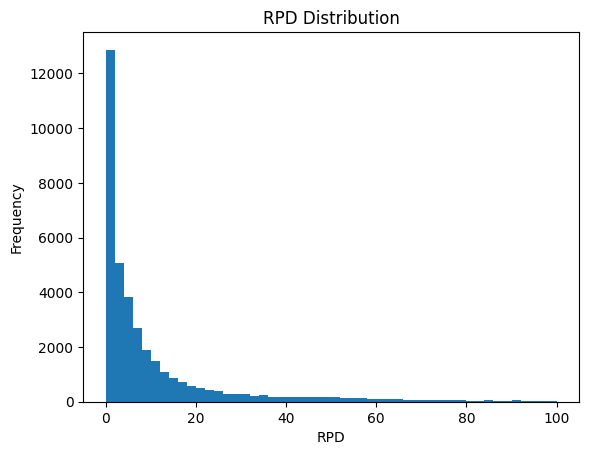

In [229]:
import matplotlib.pyplot as plt

plt.hist(msd_df['RPD'], bins=50)
plt.title("RPD Distribution")
plt.xlabel("RPD")
plt.ylabel("Frequency")
plt.show()


The histogram shows that RPD values are highly right-skewed, with most values concentrated at low levels and a long tail extending to higher values.

This indicates that most duplicate measurements have strong agreement, while a small number exhibit high variability and potential MSD anomalies.

In a right-skewed distribution, most observations cluster on the left with a few extreme values on the right, representing rare outliers .

This pattern confirms that anomalies are rare and supports the use of anomaly detection models, as fixed thresholds alone may not capture all abnormal cases.

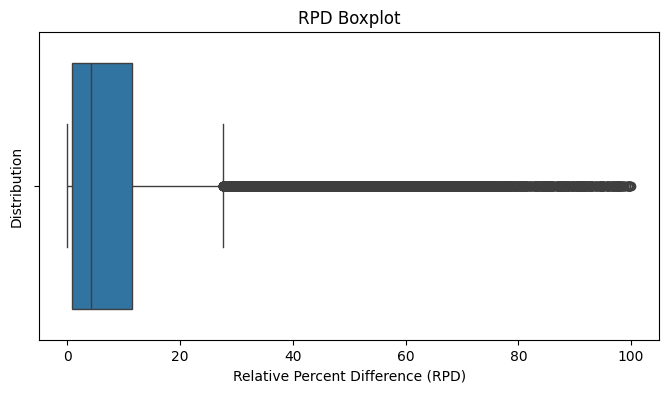

In [230]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

sns.boxplot(x=msd_df['RPD'])

plt.title("RPD Boxplot")
plt.xlabel("Relative Percent Difference (RPD)")
plt.ylabel("Distribution")

plt.show()

The boxplot shows that the majority of RPD values are concentrated at low levels, with a median around 4–5, indicating strong agreement between duplicate measurements and generally high precision.

However, the distribution is strongly right-skewed, with a long tail extending toward higher RPD values. This indicates that while most samples behave normally, a subset exhibits significantly higher variability.

Numerous extreme outliers are visible beyond the whiskers, representing cases of poor reproducibility consistent with Matrix Spike Duplicate (MSD) anomalies. In a boxplot, such points fall outside 1.5×IQR and are considered abnormal observations :contentReference[oaicite:0]{index=0}.

This skewed distribution confirms that anomalies are rare but extreme, which makes simple threshold-based methods insufficient for capturing all abnormal behaviour.

Therefore, this supports the use of:
- Rule-based thresholds for obvious anomalies (e.g., RPD > 30)
- Unsupervised machine learning models (e.g., Isolation Forest) to detect subtle and distribution-based anomalies

Overall, the boxplot provides visual evidence that anomaly detection is required and justifies the use of data-driven models for MSD anomaly detection.

Final Proposed Solution (FINAL)

The analysis shows that MSD anomalies are rare but extreme deviations in RPD values, which cannot be fully captured using fixed thresholds alone.

Therefore, a hybrid approach is proposed:

Use RPD as the core feature
Apply Isolation Forest to detect anomalies automatically
Retain rule-based thresholds (RPD > 30) for validation and interpretability

This approach improves detection by:

Capturing both obvious and subtle anomalies
Adapting to the underlying data distribution
Reducing reliance on fixed rules

In [231]:
# Rule-based anomaly (industry baseline)
msd_df['rule_anomaly'] = msd_df['RPD'] > 30

msd_df['rule_anomaly'].value_counts()

rule_anomaly
False    32966
True      3673
Name: count, dtype: int64

In [232]:
# Compare rule-based anomalies with actual QC status
msd_df.groupby('rule_anomaly')['PRECISION_STATUS'].value_counts()

rule_anomaly  PRECISION_STATUS
False         Pass                29619
              Warning              2115
              IgnoreFailure        1033
              Failure               174
True          Pass                 2089
              IgnoreFailure         949
              Warning               352
              Failure               282
Name: count, dtype: int64

In [233]:
import sys
!{sys.executable} -m pip install scikit-learn


[notice] A new release of pip available: 22.3.1 -> 26.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [234]:
from sklearn.ensemble import IsolationForest

# Use RPD as feature
X = msd_df[['RPD']]

iso = IsolationForest(contamination=0.1, random_state=42)
msd_df['iso_anomaly'] = iso.fit_predict(X)

# Convert: -1 = anomaly, 1 = normal
msd_df['iso_anomaly'] = msd_df['iso_anomaly'] == -1

msd_df['iso_anomaly'].value_counts()

iso_anomaly
False    32978
True      3661
Name: count, dtype: int64

In [235]:
msd_df.groupby('iso_anomaly')['PRECISION_STATUS'].value_counts()

iso_anomaly  PRECISION_STATUS
False        Pass                29619
             Warning              2119
             IgnoreFailure        1041
             Failure               174
True         Pass                 2089
             IgnoreFailure         941
             Warning               348
             Failure               282
Name: count, dtype: int64

Isolation Forest Evaluation

Isolation Forest correctly identifies most normal samples as “Pass” and detects a higher proportion of “Failure”, “Warning”, and “IgnoreFailure” within anomalies.

This shows the model effectively captures abnormal behaviour.

Unlike the rule-based method, it detects anomalies based on data distribution rather than a fixed threshold, allowing it to identify subtle anomalies at lower RPD values.

This confirms that Isolation Forest is more adaptive and suitable for MSD anomaly detection.

In [236]:
# Compare rule-based vs Isolation Forest
comparison = pd.DataFrame({
    "Rule-Based": msd_df['rule_anomaly'],
    "Isolation Forest": msd_df['iso_anomaly']
})

comparison.value_counts()

Rule-Based  Isolation Forest
False       False               32912
True        True                 3607
            False                  66
False       True                   54
Name: count, dtype: int64

### Model Comparison

Both methods agree on most normal samples (32,912) and clear anomalies (3,607), confirming consistency in detecting obvious patterns.

However, Isolation Forest identifies 54 additional anomalies that are not detected by the rule-based method, indicating its ability to capture subtle, distribution-based anomalies.

Conversely, 66 samples are flagged only by the rule-based approach, suggesting sensitivity to fixed threshold boundaries.

This demonstrates that Isolation Forest provides more adaptive anomaly detection by identifying patterns beyond fixed RPD thresholds, making it more suitable for detecting complex MSD anomalies.

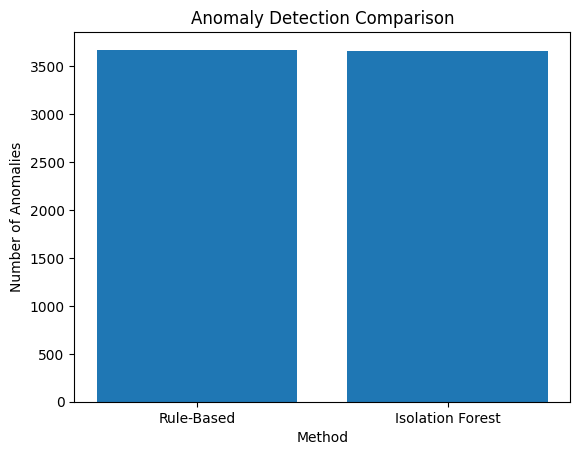

In [237]:
import matplotlib.pyplot as plt

# Compare anomaly counts
labels = ['Rule-Based', 'Isolation Forest']
values = [
    msd_df['rule_anomaly'].sum(),
    msd_df['iso_anomaly'].sum()
]

plt.bar(labels, values)
plt.title("Anomaly Detection Comparison")
plt.ylabel("Number of Anomalies")
plt.xlabel("Method")

plt.show()

### Anomaly Count Comparison

Both rule-based and Isolation Forest methods detect a similar number of anomalies, indicating consistency in identifying abnormal behaviour.

This shows that Isolation Forest does not over-detect anomalies, but aligns with established QC thresholds.

Combined with earlier results, this confirms that Isolation Forest provides a more adaptive approach while maintaining agreement with rule-based detection.